In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("Powerplant dataset.csv")

In [3]:
df

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43
...,...,...,...,...,...
9563,15.12,48.92,1011.80,72.93,462.59
9564,33.41,77.95,1010.30,59.72,432.90
9565,15.99,43.34,1014.20,78.66,465.96
9566,17.65,59.87,1018.58,94.65,450.93


In [4]:
#AT=>TEMPERATURE
# V=>VACCUM
#AP=>PRESSURE
#RH=>HUMIDITY
#PE=>PRODUCED ENERGY

In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
X=df.drop("PE",axis=1)
y=df["PE"]

In [7]:
X

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20
...,...,...,...,...
9563,15.12,48.92,1011.80,72.93
9564,33.41,77.95,1010.30,59.72
9565,15.99,43.34,1014.20,78.66
9566,17.65,59.87,1018.58,94.65


In [8]:
y

0       480.48
1       445.75
2       438.76
3       453.09
4       464.43
         ...  
9563    462.59
9564    432.90
9565    465.96
9566    450.93
9567    451.67
Name: PE, Length: 9568, dtype: float64

In [9]:
#split out data
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
df.shape

(9568, 5)

from sklearn.preprocessing import StandardSclaer

In [12]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [13]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]])

In [14]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]])

In [15]:
 import torch
import torch.nn as nn

In [16]:
X_train_tensor=torch.tensor(X_train_scaled,dtype=torch.float32)

In [17]:
type(X_train_scaled)

numpy.ndarray

In [18]:
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [19]:
X_test_torch=torch.tensor(X_test_scaled,dtype=torch.float32)

In [20]:
type(y_train)
# y_train.shape

pandas.core.series.Series

In [21]:
from torch.utils.data import TensorDataset,DataLoader

In [22]:
train_dataset=TensorDataset(X_train_tensor,y_train_tensor)
test_data=TensorDataset(X_test_torch,y_test_tensor)

In [23]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_data,batch_size=32)

In [25]:
train_loader

# DEEP LEARNIN

In [28]:
#define our ANN Model
class ANN(nn.Module):
    def __init__(self, input_size):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st Hidden Layer
            nn.Linear(input_size, 6),
            nn.ReLU(),

            # 2nd Hidden Layer
            nn.Linear(6, 6),
            nn.ReLU(),

            # Output Layer
            nn.Linear(6, 1)
        )
    def forward(self,x):
            return self.model(x)

In [30]:
import torch.optim as optim

# Create model
model = ANN(X_train.shape[1])

# Loss function
criterion = nn.MSELoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [40]:
# TRAIN THE ANN
train_losses = []
val_losses = []

best_val_loss=float("inf")
epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()  # Clear previous gradients

        outputs = model(xb)
        loss = criterion(outputs, yb)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(
        f"Epoch {epoch+1}/{epochs} ==> Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}"
    )
    if epoch_val_loss<best_val_loss:
        best_val_loss=epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt")

Epoch 1/100 ==> Train Loss: 20.7209, Val Loss: 18.9669
Epoch 2/100 ==> Train Loss: 20.7343, Val Loss: 18.7303
Epoch 3/100 ==> Train Loss: 20.8381, Val Loss: 18.9225
Epoch 4/100 ==> Train Loss: 20.7953, Val Loss: 18.7792
Epoch 5/100 ==> Train Loss: 20.7285, Val Loss: 19.3039
Epoch 6/100 ==> Train Loss: 20.9003, Val Loss: 18.8912
Epoch 7/100 ==> Train Loss: 20.9494, Val Loss: 18.9596
Epoch 8/100 ==> Train Loss: 20.7118, Val Loss: 18.9800
Epoch 9/100 ==> Train Loss: 20.6962, Val Loss: 18.9009
Epoch 10/100 ==> Train Loss: 20.7287, Val Loss: 19.0749
Epoch 11/100 ==> Train Loss: 20.8843, Val Loss: 18.7145
Epoch 12/100 ==> Train Loss: 20.8694, Val Loss: 19.2524
Epoch 13/100 ==> Train Loss: 20.6038, Val Loss: 18.8403
Epoch 14/100 ==> Train Loss: 20.7607, Val Loss: 19.1567
Epoch 15/100 ==> Train Loss: 20.6573, Val Loss: 20.0648
Epoch 16/100 ==> Train Loss: 20.7246, Val Loss: 19.5369
Epoch 17/100 ==> Train Loss: 20.7448, Val Loss: 18.7463
Epoch 18/100 ==> Train Loss: 20.6763, Val Loss: 19.5679
E

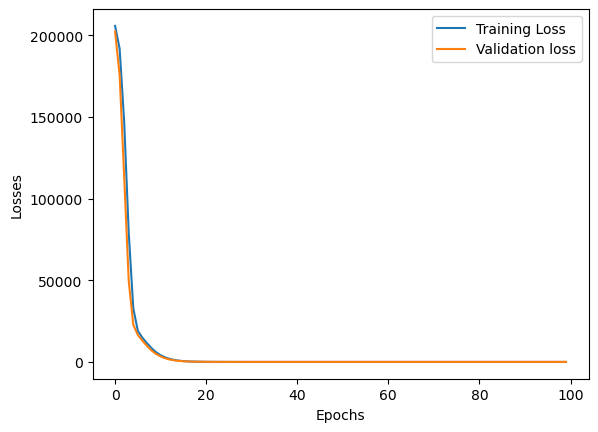

In [32]:
import matplotlib.pyplot as plt

loss_df=pd.DataFrame({
    "train_loss":train_losses,
    "validation_loss":val_losses
})

plt.plot(loss_df["train_loss"],label="Training Loss")
plt.plot(loss_df["validation_loss"],label="Validation loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [42]:
#loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [56]:
model.eval()

with torch.no_grad():
    train_predict = model(X_train_tensor)
    test_predict = model(X_test_torch)

    train_mse_loss = criterion(train_predict, y_train_tensor)
    test_mse_loss = criterion(test_predict, y_test_tensor)

print("Train Loss:", train_mse_loss.item())
print("Test Loss:", test_mse_loss.item())

Train Loss: 20.338083267211914
Test Loss: 18.650835037231445


In [60]:
from sklearn.metrics import r2_score

print("r2_score=",r2_score(y_test,test_predict))

r2_score= 0.9348201411701053


In [66]:
predicted_df=pd.DataFrame(test_predict.numpy(),columns=["predicted values"])
actual_df=pd.DataFrame(y_test.values,columns=["Actual values"])
pd.concat([predicted_df,actual_df],axis=1)

,predicted values,Actual values
0,435.355438,433.27
1,436.671509,438.16
2,461.204010,458.42
3,476.123810,480.82
4,435.125153,441.41
...,...,...
1909,451.371277,456.70
1910,431.516693,438.04
1911,467.773987,467.80
1912,430.867401,437.14
